KL散度 衡量两个概率分布P、Q的差异

https://www.bilibili.com/video/BV1Y57jzfE6N/?spm_id_from=333.337.search-card.all.click&vd_source=8c7abd9bc14823124fe665c92c1f2ddd

前向KL计算 用Q模型分布去拟合P真实分布 常用于监督学习、模型蒸馏
前向KL计算 用Q模型分布去拟合P真实分布 Q可以忽略P的一些小概率区域，只捕捉主要模式 常用于VAE、强化学习、生成模型

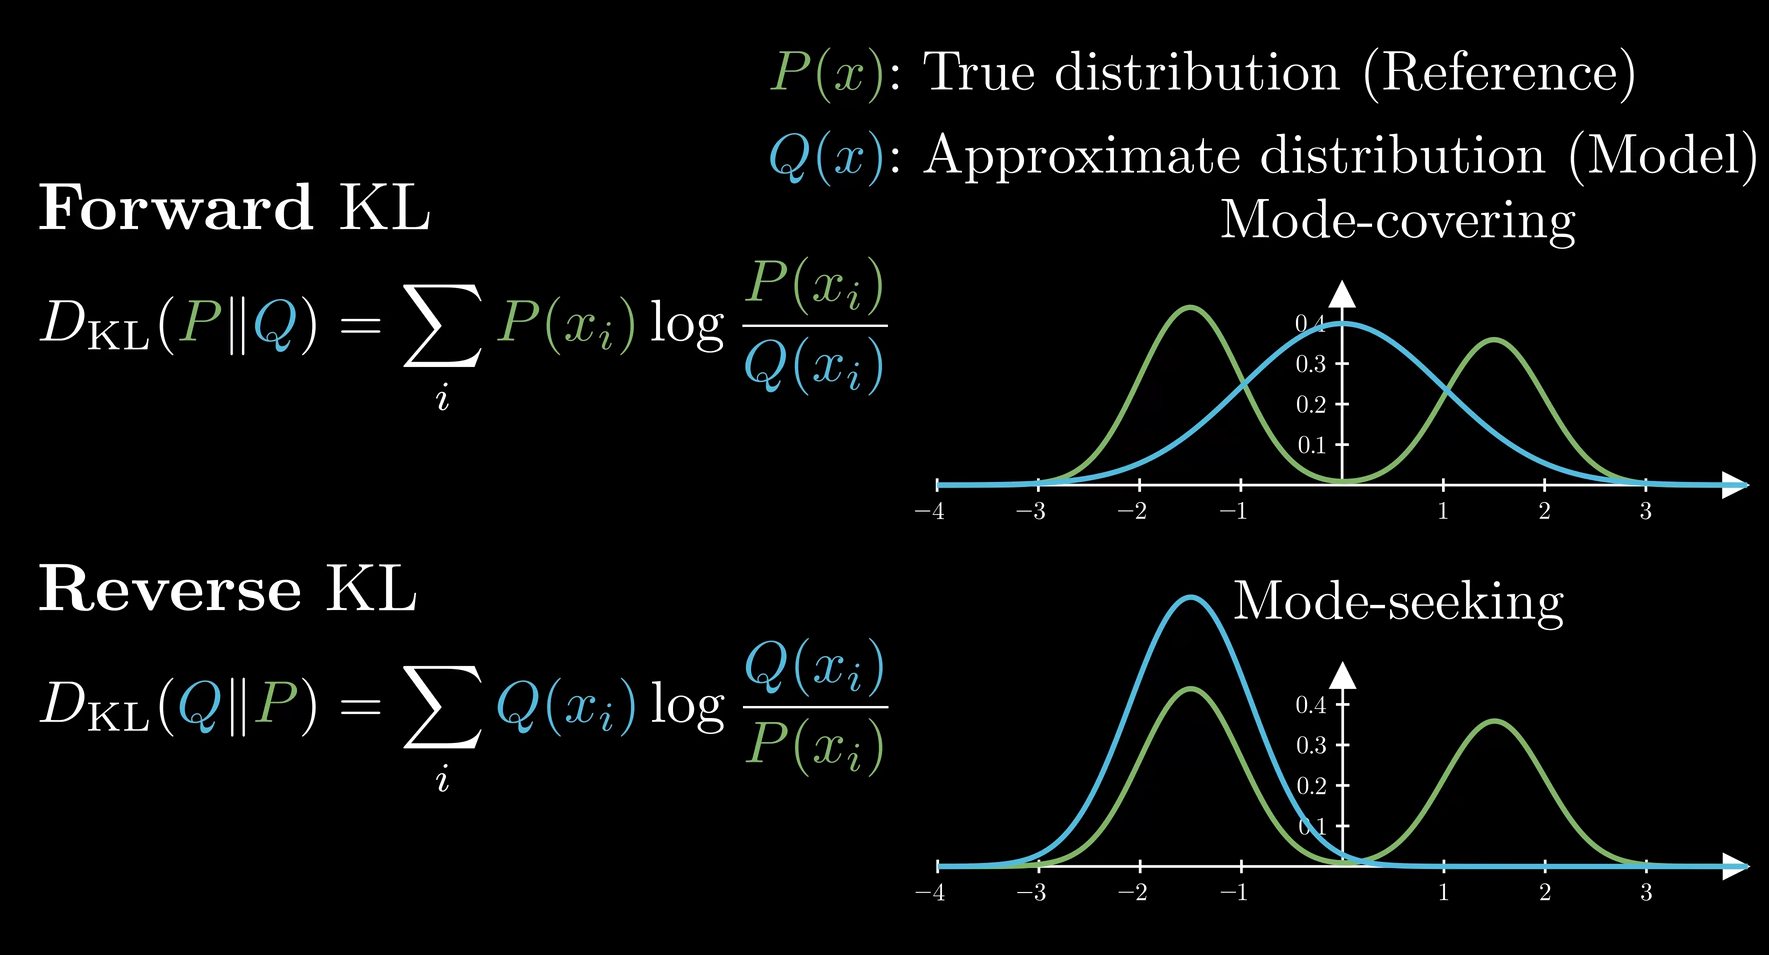



In [2]:
import torch

def softmax(x):
    max_x = torch.max(x,dim=-1,keepdim=True)[0]
    ex_fenzi = torch.exp(x-max_x)
    ex_fenmu = torch.sum(ex_fenzi,dim=-1,keepdim=True)
    return ex_fenzi/ex_fenmu

def kl(p_logits,q_logits):
    eps = 1e-9
    p_prob = softmax(p_logits)
    q_prob = softmax(q_logits) 
    p_log_prob= torch.log(p_prob + eps)
    q_log_prob= torch.log(q_prob + eps)
    kl_div = p_prob * (p_log_prob - q_log_prob)
    return torch.sum(kl_div,dim = -1)


